<a href="https://colab.research.google.com/github/asheta66/Capuchin-search-algorithm-CapSA-/blob/master/OSA/Hybrid_Neuroevolution_Code_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# ================================
# INSTALL DEPENDENCIES
# ================================
# !pip install -q imbalanced-learn scikit-learn pandas numpy matplotlib

In [37]:
# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE


# ================================
# LOAD DATA
# ================================
df = pd.read_csv("OSA_2023_processed.csv")
target_col = "OSA"

X = df.drop(columns=[target_col]).values
y = df[target_col].values

print("Original dataset:", X.shape)
print("Class distribution:", pd.Series(y).value_counts().to_dict())


# ================================
# NORMALIZATION
# ================================
scaler = StandardScaler()
X = scaler.fit_transform(X)


# ================================
# TRAIN / TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


Original dataset: (1000, 8)
Class distribution: {1: 565, 0: 435}


In [38]:
y_train_before = y_train.copy()
X_train_before = X_train.copy()

In [39]:
# ================================
# SMOTE BALANCING
# ================================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train.shape)

After SMOTE: (790, 8)


In [40]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train.shape)

After SMOTE: (790, 8)


In [41]:



# ================================
# SIMPLE NEURAL NETWORK
# ================================
class SimpleNN:
    def __init__(self, input_dim, hidden=16):
        self.input_dim = input_dim
        self.hidden = hidden
        self.output = 1

    def dim(self):
        return (self.input_dim*self.hidden +
                self.hidden +
                self.hidden*self.output +
                self.output)

    def set_weights(self, w):
        idx = 0
        self.W1 = w[idx:idx+self.input_dim*self.hidden].reshape(self.input_dim, self.hidden)
        idx += self.input_dim*self.hidden

        self.b1 = w[idx:idx+self.hidden]
        idx += self.hidden

        self.W2 = w[idx:idx+self.hidden*self.output].reshape(self.hidden, self.output)
        idx += self.hidden*self.output

        self.b2 = w[idx:idx+self.output]

    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = np.tanh(Z1)
        Z2 = A1 @ self.W2 + self.b2
        return 1 / (1 + np.exp(-Z2))

    def train(self, X, y, lr=1e-3, epochs=5):
        y = y.reshape(-1, 1)

        for _ in range(epochs):
            y_hat = self.forward(X)

            dZ2 = y_hat - y
            dW2 = (np.tanh(X @ self.W1 + self.b1)).T @ dZ2
            db2 = np.sum(dZ2, axis=0)

            dA1 = dZ2 @ self.W2.T
            Z1 = X @ self.W1 + self.b1
            dZ1 = dA1 * (1 - np.tanh(Z1)**2)

            dW1 = X.T @ dZ1
            db1 = np.sum(dZ1, axis=0)

            self.W1 -= lr * dW1
            self.b1 -= lr * db1
            self.W2 -= lr * dW2
            self.b2 -= lr * db2

    def clone(self):
        return SimpleNN(self.input_dim, self.hidden)


# ================================
# MODEL
# ================================
model = SimpleNN(X.shape[1])
DIM = model.dim()


# ================================
# FITNESS FUNCTION
# ================================
def fitness(solution):
    net = model.clone()
    net.set_weights(solution)

    net.train(X_train, y_train, epochs=5, lr=1e-3)

    preds = net.forward(X_train).ravel()
    return auc(*roc_curve(y_train, preds)[:2])


# ================================
# CUSTOM GA
# ================================
class GA:
    def __init__(self, pop_size=25, generations=15, pc=0.8, pm=0.02):
        self.pop_size = pop_size
        self.generations = generations
        self.pc = pc
        self.pm = pm

        self.pop = np.random.uniform(-1, 1, (pop_size, DIM))
        self.best_history = []

    # ================================
    # 🔥 ADD THIS (FIX)
    # ================================
    def tournament(self):
        i, j = np.random.randint(0, self.pop_size, 2)
        return i if fitness(self.pop[i]) > fitness(self.pop[j]) else j

    def crossover(self, p1, p2):
        if np.random.rand() < self.pc:
            a = np.random.rand()
            return a * p1 + (1 - a) * p2
        return p1.copy()

    def mutate(self, child):
        for i in range(len(child)):
            if np.random.rand() < self.pm:
                child[i] += np.random.normal(0, 0.1)
        return child

    def evolve(self):
        best, best_fit = None, -np.inf

        for g in range(self.generations):
            new_pop = []

            for _ in range(self.pop_size):
                p1 = self.pop[self.tournament()]
                p2 = self.pop[self.tournament()]

                child = self.crossover(p1, p2)
                child = self.mutate(child)

                new_pop.append(child)

            self.pop = np.array(new_pop)

            fits = [fitness(ind) for ind in self.pop]
            idx = np.argmax(fits)

            if fits[idx] > best_fit:
                best_fit = fits[idx]
                best = self.pop[idx]

            self.best_history.append(best_fit)

            print(f"Gen {g}: Best AUC = {best_fit:.4f}")

        return best, best_fit

# ================================
# RUN GA
# ================================
ga = GA()
best_solution, best_score = ga.evolve()


# ================================
# FINAL MODEL
# ================================
net = model.clone()
net.set_weights(best_solution)

net.train(X_train, y_train, epochs=10)

# ================================
# PREDICTIONS
# ================================
train_prob = net.forward(X_train).ravel()
test_prob = net.forward(X_test).ravel()

train_pred = (train_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

# ================================
# METRICS FUNCTION
# ================================
import pandas as pd

# ================================
# COMBINE RESULTS INTO DATAFRAME
# ================================
df_metrics = pd.DataFrame([
    {
        "Set": "Train",
        "Accuracy": train_metrics["Accuracy"],
        "Precision": train_metrics["Precision"],
        "Recall": train_metrics["Recall"],
        "F1-score": train_metrics["F1"]
    },
    {
        "Set": "Test",
        "Accuracy": test_metrics["Accuracy"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"],
        "F1-score": test_metrics["F1"]
    }
])


Gen 0: Best AUC = 0.7543
Gen 1: Best AUC = 0.7646
Gen 2: Best AUC = 0.7696
Gen 3: Best AUC = 0.7739
Gen 4: Best AUC = 0.7739
Gen 5: Best AUC = 0.7739
Gen 6: Best AUC = 0.7766
Gen 7: Best AUC = 0.7822
Gen 8: Best AUC = 0.7845
Gen 9: Best AUC = 0.7908
Gen 10: Best AUC = 0.7927
Gen 11: Best AUC = 0.7953
Gen 12: Best AUC = 0.8010
Gen 13: Best AUC = 0.8035
Gen 14: Best AUC = 0.8065


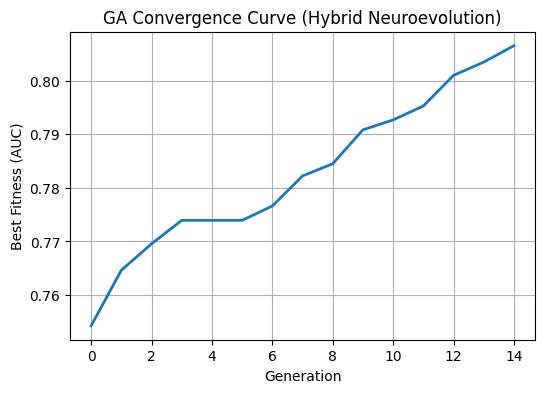

In [42]:
# ================================
# CONVERGENCE CURVE
# ================================
plt.figure(figsize=(6,4))

plt.plot(ga.best_history, linewidth=2)

plt.title("GA Convergence Curve (Hybrid Neuroevolution)")
plt.xlabel("Generation")
plt.ylabel("Best Fitness (AUC)")
plt.grid(True)

plt.show()

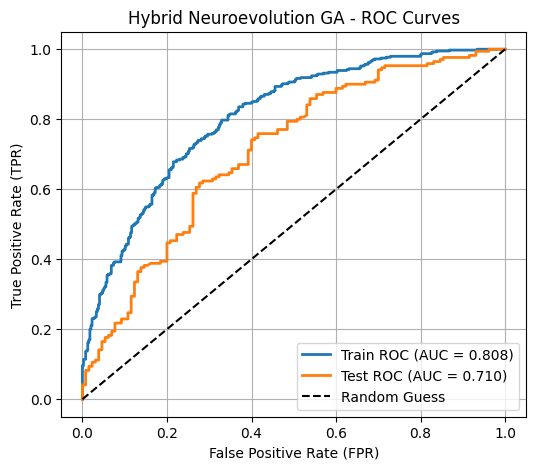

In [43]:
# ================================
# ROC CURVE (TRAIN + TEST)
# ================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

# --- TRAIN ROC ---
fpr_train, tpr_train, _ = roc_curve(y_train, train_prob)
roc_auc_train = auc(fpr_train, tpr_train)

# --- TEST ROC ---
fpr_test, tpr_test, _ = roc_curve(y_test, test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

# ================================
# PLOT
# ================================
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(6, 5))

# Train curve
plt.plot(
    fpr_train, tpr_train,
    label=f"Train ROC (AUC = {roc_auc_train:.3f})",
    linewidth=2
)

# Test curve
plt.plot(
    fpr_test, tpr_test,
    label=f"Test ROC (AUC = {roc_auc_test:.3f})",
    linewidth=2
)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

# Styling (IEEE-friendly)
plt.title("Hybrid Neuroevolution GA - ROC Curves")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(True)
plt.legend(loc="lower right")

plt.show()

In [44]:
# ================================
# DISPLAY
# ================================
print("\n================ FINAL METRICS DATAFRAME ================")
df_metrics


================ FINAL METRICS DATAFRAME ================


,Set,Accuracy,Precision,Recall,F1-score
0,Train,0.756962,0.745763,0.779747,0.762376
1,Test,0.660000,0.715190,0.664706,0.689024


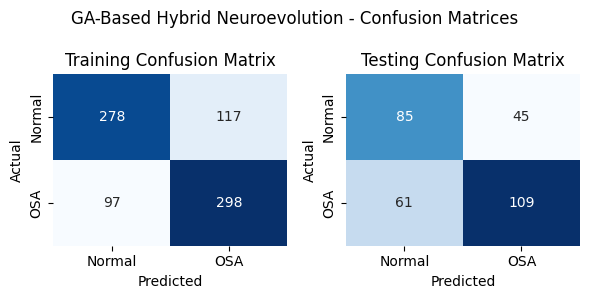

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ================================
# CONFUSION MATRICES
# ================================
train_cm = confusion_matrix(y_train, train_pred)
test_cm = confusion_matrix(y_test, test_pred)

# ================================
# FIGURE SETUP (IEEE STYLE)
# ================================
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# ================================
# TRAIN CM
# ================================
sns.heatmap(
    train_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "OSA"],
    yticklabels=["Normal", "OSA"],
    ax=axes[0]
)
axes[0].set_title("Training Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ================================
# TEST CM
# ================================
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "OSA"],
    yticklabels=["Normal", "OSA"],
    ax=axes[1]
)
axes[1].set_title("Testing Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ================================
# FINAL LAYOUT
# ================================
plt.suptitle("GA-Based Hybrid Neuroevolution - Confusion Matrices", fontsize=12)
plt.tight_layout()
plt.show()

In [46]:
import pandas as pd

# BEFORE SMOTE
before_counts = pd.Series(y_train_before).value_counts().sort_index()

# AFTER SMOTE
after_counts = pd.Series(y_train).value_counts().sort_index()

print("\n================ BEFORE SMOTE ================")
print(before_counts)
print("Total samples:", len(y_train_before))

print("\n================ AFTER SMOTE ================")
print(after_counts)
print("Total samples:", len(y_train))


# ================================
# IEEE TABLE FORMAT
# ================================
df_aug = pd.DataFrame({
    "Class": before_counts.index,
    "Before_SMOTE": before_counts.values,
    "After_SMOTE": after_counts.values
})

display(df_aug)


================ BEFORE SMOTE ================
0    305
1    395
Name: count, dtype: int64
Total samples: 700

================ AFTER SMOTE ================
0    395
1    395
Name: count, dtype: int64
Total samples: 790


,Class,Before_SMOTE,After_SMOTE
0,0,305,395
1,1,395,395
